# 다음 영화 리뷰의 키워드 분석

1. 데이터 준비(로딩)
2. 텍스트 전처리(토큰화, 불용어 제거)
3. 빈도수 분석(Counter)

* 시각화 1: 수평 막대그래프
* 시각화 2 : 워드 클라우드

In [2]:
#데이터 준비 (로딩)
data_filename = './data/daum_movie_review.csv'

import pandas as pd
movie_df = pd.read_csv(data_filename)
#movie_df.head()
review_list = list(movie_df.review)
review_list[:10]

['돈 들인건 티가 나지만 보는 내내 하품만',
 '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
 '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
 '이 정도면 볼만하다고 할 수 있음!',
 '재미있다',
 '나는 재밌게 봄',
 '0.5점은 줄 수 없냐?',
 '헐..다 죽었어....나중에 앤트맨 보다가도 깜놀...',
 '충격 결말',
 '응집력']

In [3]:
from konlpy.tag import Okt
tagger = Okt()

# 모든 리뷰를 하나로 합쳐서 형태소 분석
movie_doc = " ".join(review_list)
pos_list = tagger.pos(movie_doc)

# 명사, 동사, 형용사만 추출 
my_tags = ['Noun', 'Verb', 'Adjective']
my_tokens = [word for word, tag in pos_list if tag in my_tags]
print(f"추출된 토큰 수: {len(my_tokens)}")

추출된 토큰 수: 194792


In [4]:
from collections import Counter

# 불용어 리스트 (사용자님이 분석하신 소음들 제거)
my_stopwords = ['영화', '정말', '진짜', '하는', '입니다', '좀', '그', '이', '것', '잘', '점', 
    '수', '나', '내', '들', '보', '본', '보고', '하고', '있는', '생각', '사람', '더', '그냥', '정도', '할','볼','꼭','왜','때','봤는데','보는','느낌']
my_new_tokens = [token for token in my_tokens if token not in my_stopwords]

# 빈도수 계산
word_counts = Counter(my_new_tokens)
top_20 = word_counts.most_common(20)
print(top_20)

[('연기', 1293), ('감동', 1223), ('배우', 847), ('스토리', 815), ('눈물', 737), ('최고', 682), ('재미', 641), ('마지막', 612), ('시간', 596), ('마동석', 556), ('광주', 530), ('윤계상', 517), ('기대', 516), ('내용', 494), ('돈', 489), ('장면', 438), ('원작', 422), ('말', 420), ('평점', 407), ('신파', 387)]


그래프가 저장되었습니다: ./result/daum_movie_review_graph.jpg


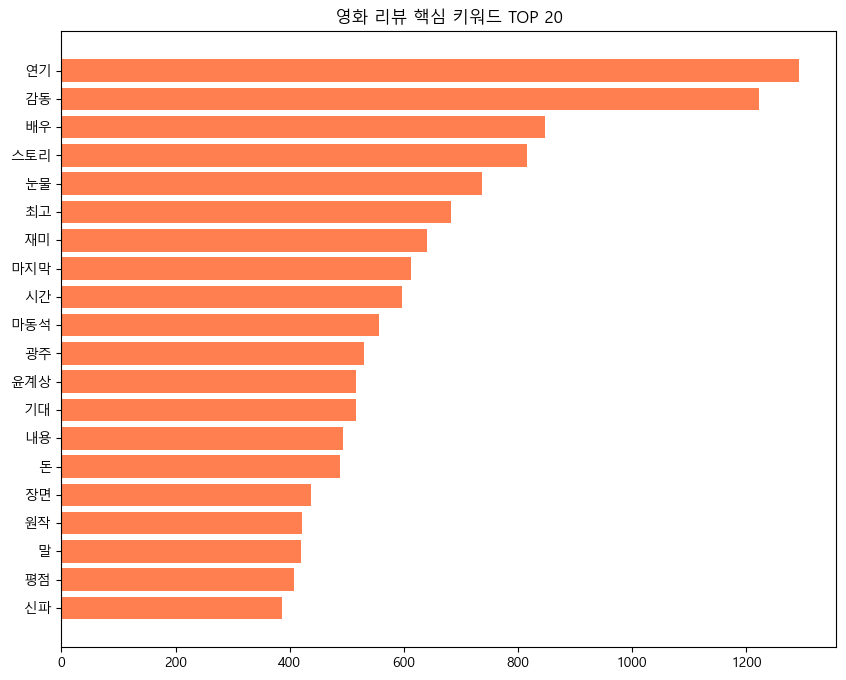

In [8]:
import matplotlib.pyplot as plt
import os

# 한글 폰트 및 마이너스 기호 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

labels, values = zip(*top_20)

plt.figure(figsize=(10, 8))
plt.barh(labels[::-1], values[::-1], color='coral')
plt.title("영화 리뷰 핵심 키워드 TOP 20")

# 파일 저장 로직 (입력 파일명을 기반으로 결과 파일명 생성)
graph_filename ='./result/' + os.path.basename(data_filename).replace('.csv', '_graph.jpg')
plt.savefig(graph_filename)
print(f"그래프가 저장되었습니다: {graph_filename}")
plt.show()

워드클라우드가 저장되었습니다: ./result/daum_movie_review_wordcloud.jpg


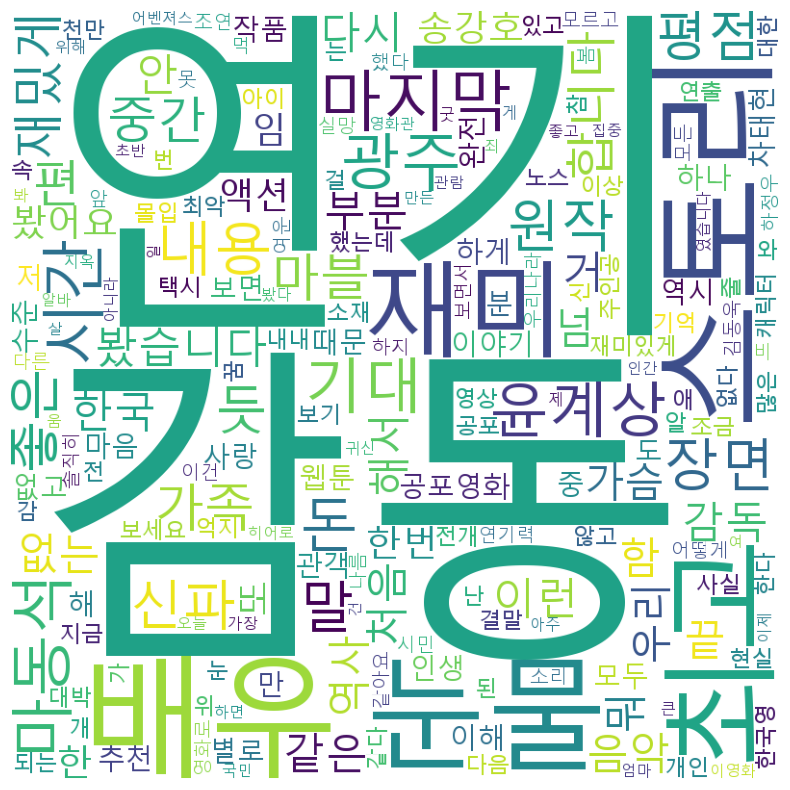

In [10]:
from wordcloud import WordCloud

# 워드클라우드 생성
wc = WordCloud(font_path='malgun', background_color='white', width=800, height=800)
cloud = wc.generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 10))
plt.imshow(cloud)
plt.axis('off')

# 워드클라우드 저장 로직
cloud_filename = './result/' + os.path.basename(data_filename).replace('.csv', '_wordcloud.jpg')
wc.to_file(cloud_filename)
print(f"워드클라우드가 저장되었습니다: {cloud_filename}")
plt.show()